# 26 &middot; Sparse Meshless Models: control frames that know the material

A character is not one material: bones are stiff, flesh is soft, and the two meet at sharp interfaces. A subspace built from
geometry alone (tutorial&nbsp;17's skinning eigenmodes, radial basis functions, barycentric coordinates) spreads every
control frame's influence smoothly across those interfaces, so it needs many frames to bend a joint without also bending
the bone next to it. *Sparse Meshless Models of Complex Deformable Solids* (Faure, Gilles, Bousquet, Pai, SIGGRAPH 2011)
fixes this with one idea: measure distance in **compliance** instead of in metres. Two points joined by stiff material are
*close* (they move together), two points joined by soft material are *far*. Nodes, Voronoi regions and skinning weights
all follow from that one metric, and a handful of affine frames resolves a heterogeneous body. Our test body is a
tapered tentacle with three stiff segments and two wide soft joints.

$$d(a,b) \;=\; \min_{\text{paths } a\to b}\ \int \frac{1}{E(s)}\,\mathrm{d}s, \qquad E = \text{Young's modulus}.$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import warnings
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import igl
import simkit
import utils

warnings.filterwarnings("ignore", category=sp.linalg.LinAlgWarning)   # stiff pin -> benign ill-conditioning

NOTEBOOK = "026_sparse_meshless_models"                           # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK)               # results/026_sparse_meshless_models/
MEDIA_DIR = "media"                                               # tracked copies for the website
# tentacle: a tapered capsule with three stiff segments joined by two soft joints, pinned at its base
LENGTH, R_BASE, R_TIP = 4.0, 0.6, 0.45         # body length and half-thickness at the base / tip (caps added)
SEGMENTS = [(-1.0, 0.9), (1.5, 2.5), (3.1, 5.0)]   # x-ranges of the stiff segments (the 0.6-wide gaps are the joints)
MAX_AREA = 0.004                                # Triangle's maximum triangle area
PIN_X = -0.3                                    # vertices with x <= PIN_X are pinned (inside the base segment)
# material
MATERIAL = "macklin-mueller-neo-hookean"
YM_SOFT, YM_STIFF = 1.0e3, 1.0e6  # Young's modulus of joints / segments (ratio 1000)
PR = 0.4                          # Poisson ratio
RHO = 1.0                         # density
GRAVITY = -9.8                    # vertical gravitational acceleration
K_PIN = 1e9                       # stiffness of the wall pin and of the handle springs
# sparse meshless model
N_NODES = 9                       # control frames; skinning eigenmodes gets the same number of bones
SUPPORT_SCALE = 1.0               # weight support radius / distance to the nearest node (1 = compact tents)
LLOYD_ITERS = 8                   # Lloyd relaxation passes of the node placement
N_WEIGHTS_SHOWN = 3               # weight columns drawn below (one per stiff segment)
SWEEP_NODES = [3, 6, 9, 12, 18, 24]   # frame counts of the convergence sweep
# solver and checks
NEWTON_ITERS = 150                # max Newton iterations per solve
NEWTON_TOL = 1e-6                 # stop when the Newton step is shorter than this
PATCH_ANGLE_DEG = 30.0            # rotation of the affine patch test
# handle sweep
N_FRAMES = 36                     # frames of the swing animation
SWING_DEG = 40.0                  # peak angle of the free end's arc
FPS = 12                          # playback rate of the animation
BITRATE = 1800                    # mp4 bitrate
# plot colors
FULL_C, SKIN_C, SM_C = "#d62728", "#7570b3", "#1b9e77"   # full FEM, skinning eigenmodes, sparse meshless

/home/user/simkit/simkit/__init__.py:262: UserWarning: simkit: some functionality is unavailable because optional dependencies are not installed:
  [viz] (missing: polyscope) -> pip install 'simkit[viz]'
  _emit_missing_warning()


## 1 &middot; A tentacle with stiff segments and soft joints

`utils.tapered_capsule_mesh` meshes a rounded body, $1.2$ thick at the base and $0.9$ at the tip, with Triangle, and
`tentacle_material` assigns each triangle a Young's modulus by the $x$ of its centroid: $10^6$ inside the three
**stiff segments** (the "bones") and $10^3$ in the two $0.6$-wide **joints** between them, a thousand times softer. The
segment boundaries are passed to the mesher as constraint lines so no triangle straddles a material interface.
`simkit.ympr_to_lame` turns the per-element modulus into the per-element Lamé parameters the elastic energy takes.
The base (blue squares) is pinned; the orange dot is the tip vertex we track.

tentacle: 1093 vertices, 2010 triangles, 2186 DOFs; 1514 stiff triangles, 496 soft triangles


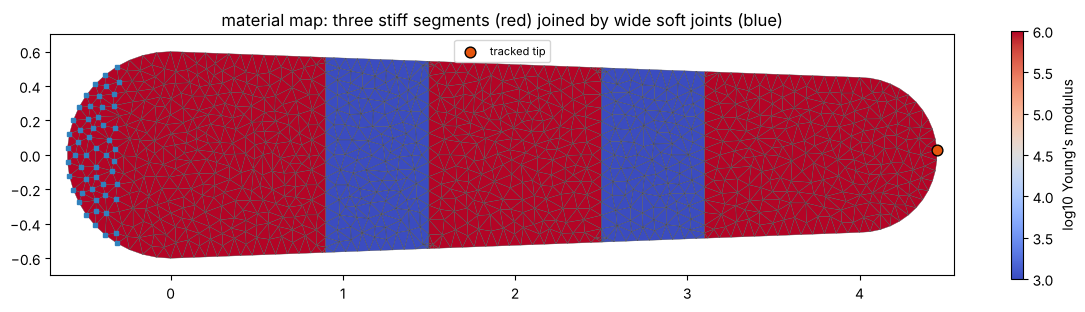

In [2]:
def tentacle_material(X, T):
    """Per-triangle Young's modulus: YM_STIFF inside SEGMENTS, YM_SOFT in the joints between them."""
    cx = X[T].mean(axis=1)[:, 0]                          # triangle centroid x
    in_segment = np.zeros(len(T), dtype=bool)
    for lo, hi in SEGMENTS:
        in_segment |= (cx >= lo) & (cx <= hi)
    return np.where(in_segment, YM_STIFF, YM_SOFT)

interfaces = [xb for lo, hi in SEGMENTS for xb in (lo, hi)]
X, T = utils.tapered_capsule_mesh(LENGTH, R_BASE, R_TIP, interfaces, max_area=MAX_AREA)
ym = tentacle_material(X, T)
n, dim = X.shape
mu_e, lam_e = simkit.ympr_to_lame(ym, PR)                 # per-element Lame parameters
mu, lam = mu_e.reshape(-1, 1), lam_e.reshape(-1, 1)
pin_idx = np.where(X[:, 0] <= PIN_X)[0]
handle_idx = np.where(X[:, 0] >= LENGTH)[0]               # the tip cap
tip = int(np.argmax(X[:, 0]))
print(f"tentacle: {n} vertices, {len(T)} triangles, {X.size} DOFs; "
      f"{(ym == YM_STIFF).sum()} stiff triangles, {(ym == YM_SOFT).sum()} soft triangles")

fig, ax = plt.subplots(figsize=(12, 3.4))
utils.plot_scalar_field(ax, X, T, np.log10(ym), cmap="coolwarm", edges=True, label="log10 Young's modulus",
                        title="material map: three stiff segments (red) joined by wide soft joints (blue)")
ax.plot(*X[pin_idx].T, "s", color=utils.PIN_C, ms=3, zorder=6)
ax.scatter(*X[tip], s=60, color=utils.HANDLE_C, edgecolors="k", zorder=6, label="tracked tip")
ax.legend(loc="upper center", fontsize=8)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "material.png"),
                              copy_to=os.path.join(MEDIA_DIR, "026_material.png"))
plt.show()

## 2 &middot; The compliance distance

`simkit.compliance_graph` weights every mesh edge by its length times the compliance $1/E$ of the triangles it borders,
and `simkit.compliance_distances` runs Dijkstra on that graph. Measured from the tip (orange), the ordinary geodesic
distance grows steadily along the body, while the compliance distance barely moves inside a stiff segment and jumps
across each joint: in this metric a segment is nearly a single point and the tentacle is a chain of three points joined
by two long soft springs. The lower plot follows both distances along the midline, each normalised to its maximum.

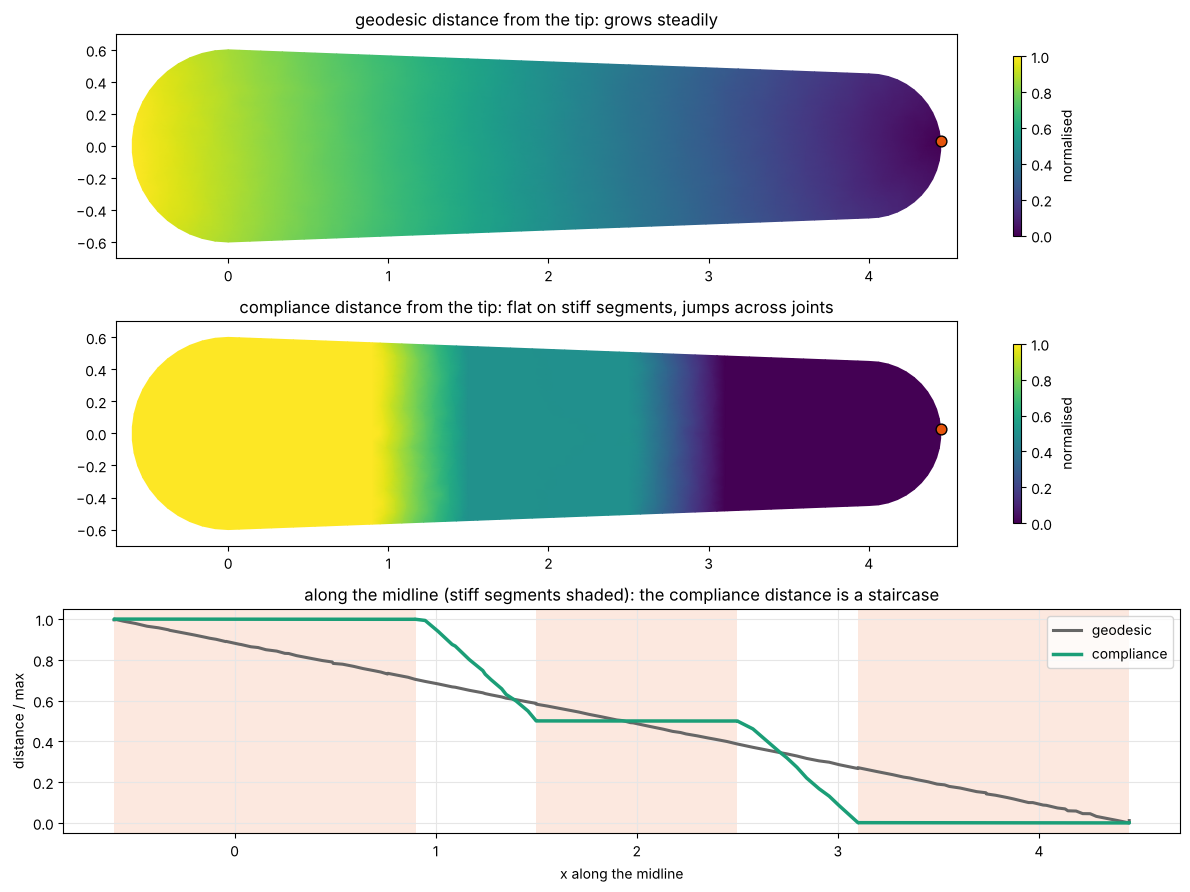

In [3]:
G_compliance = simkit.compliance_graph(X, T, ym)                   # edge weights: length / E
G_geodesic = simkit.compliance_graph(X, T, np.ones(len(T)))         # uniform material -> plain edge lengths
d_compliance = simkit.compliance_distances(G_compliance, tip)[0]
d_geodesic = simkit.compliance_distances(G_geodesic, tip)[0]

mid_row = np.where(np.abs(X[:, 1]) < 0.06)[0]                     # vertices near the midline y = 0
mid_row = mid_row[np.argsort(X[mid_row, 0])]
fig, axes = plt.subplots(3, 1, figsize=(12, 9.0), gridspec_kw={"height_ratios": [1, 1, 1.0]})
utils.plot_scalar_field(axes[0], X, T, d_geodesic / d_geodesic.max(), edges=False, label="normalised",
                        title="geodesic distance from the tip: grows steadily")
utils.plot_scalar_field(axes[1], X, T, d_compliance / d_compliance.max(), edges=False, label="normalised",
                        title="compliance distance from the tip: flat on stiff segments, jumps across joints")
for ax in axes[:2]:
    ax.scatter(*X[tip], s=60, color=utils.HANDLE_C, edgecolors="k", zorder=6)
axes[2].plot(X[mid_row, 0], d_geodesic[mid_row] / d_geodesic.max(), color="0.4", lw=2.2, label="geodesic")
axes[2].plot(X[mid_row, 0], d_compliance[mid_row] / d_compliance.max(), color=SM_C, lw=2.5, label="compliance")
for lo, hi in SEGMENTS:
    axes[2].axvspan(max(lo, X[:, 0].min()), min(hi, X[:, 0].max()), color="#f4a582", alpha=0.25, lw=0)
axes[2].set_xlabel("x along the midline"); axes[2].set_ylabel("distance / max")
axes[2].set_title("along the midline (stiff segments shaded): the compliance distance is a staircase")
axes[2].grid(True, color="0.9"); axes[2].legend(loc="upper right")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "distances.png"),
                              copy_to=os.path.join(MEDIA_DIR, "026_distances.png"))
plt.show()

## 3 &middot; Placing the control nodes where the compliance is

`simkit.compliance_node_sampling` runs farthest-point sampling in the compliance metric and then Lloyd relaxation (each
node moves to the centre of its region), the compliance analogue of `simkit.farthest_point_sampling`. Because a stiff
segment is tiny in this metric and a joint is long, the same nine nodes land differently: Euclidean sampling spreads
them evenly over the body, compliance sampling spends most of them on the joints, where the deformation will actually
happen, and gives each stiff segment no more than it needs.

Euclidean sampling : 1 of 9 nodes in the joints
compliance sampling: 6 of 9 nodes in the joints


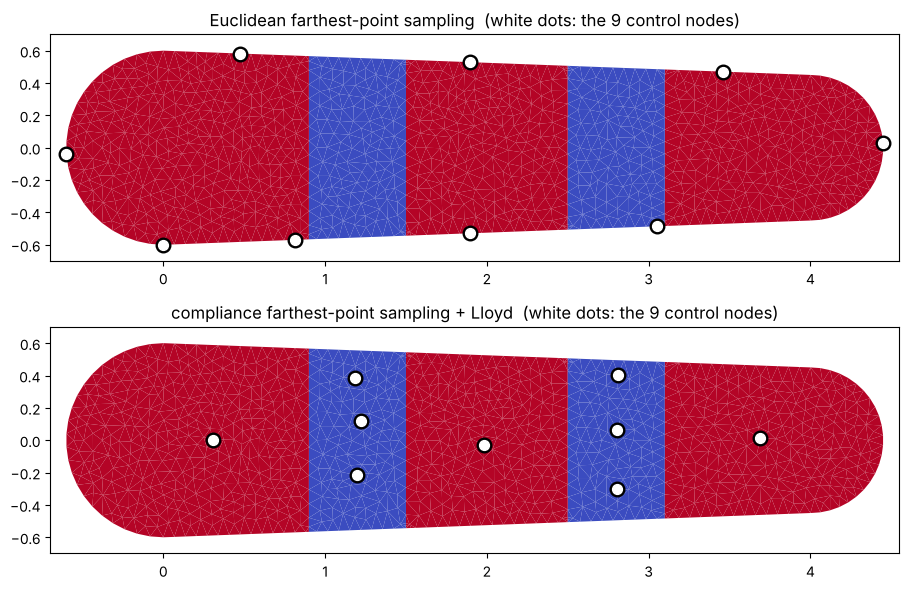

In [4]:
nodes_euclid = simkit.farthest_point_sampling(X, N_NODES)
nodes = simkit.compliance_node_sampling(X, G_compliance, N_NODES, lloyd_iters=LLOYD_ITERS)

def in_joint(idx):
    """True for the nodes whose x lies in a joint (outside every stiff segment)."""
    x = X[idx, 0]
    inside = np.zeros(len(idx), dtype=bool)
    for lo, hi in SEGMENTS:
        inside |= (x >= lo) & (x <= hi)
    return ~inside

print(f"Euclidean sampling : {in_joint(nodes_euclid).sum()} of {N_NODES} nodes in the joints")
print(f"compliance sampling: {in_joint(nodes).sum()} of {N_NODES} nodes in the joints")

fig, axes = plt.subplots(2, 1, figsize=(12, 6.0))
for ax, idx, name in zip(axes, [nodes_euclid, nodes], ["Euclidean farthest-point sampling",
                                                       "compliance farthest-point sampling + Lloyd"]):
    utils.plot_scalar_field(ax, X, T, np.log10(ym), cmap="coolwarm", edges=False, colorbar=False,
                            title=f"{name}  (white dots: the {N_NODES} control nodes)")
    ax.scatter(*X[idx].T, s=110, color="k", marker="o", zorder=6)
    ax.scatter(*X[idx].T, s=50, color="w", marker="o", zorder=7)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "nodes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "026_nodes.png"))
plt.show()

## 4 &middot; Voronoi regions and material-aware skinning weights

With the node-to-vertex compliance distances in hand, `simkit.voronoi_labels` assigns every triangle to its nearest node
and `simkit.voronoi_shape_functions` builds the skinning weights: each node gets a clamped-linear tent in the compliance
metric ($1$ at the node, $\tfrac12$ at the Voronoi frontier, $0$ at the nearest other node), normalised to a partition of
unity. Crossing a joint is expensive, so a segment node's weight is constant across its segment and fades linearly
through the joint, and a joint node's weight never leaks into the stiff segments. The printout checks the three
properties a skinning basis needs; the figure shows the Voronoi regions and the weight of one node per stiff segment.

W: (1093, 9), 2699 non-zeros (27% dense)
  partition of unity : max |row sum - 1| = 2.2e-16
  non-negative       : min W = 0.0e+00
  interpolating      : max |W[nodes] - I| = 0.0e+00


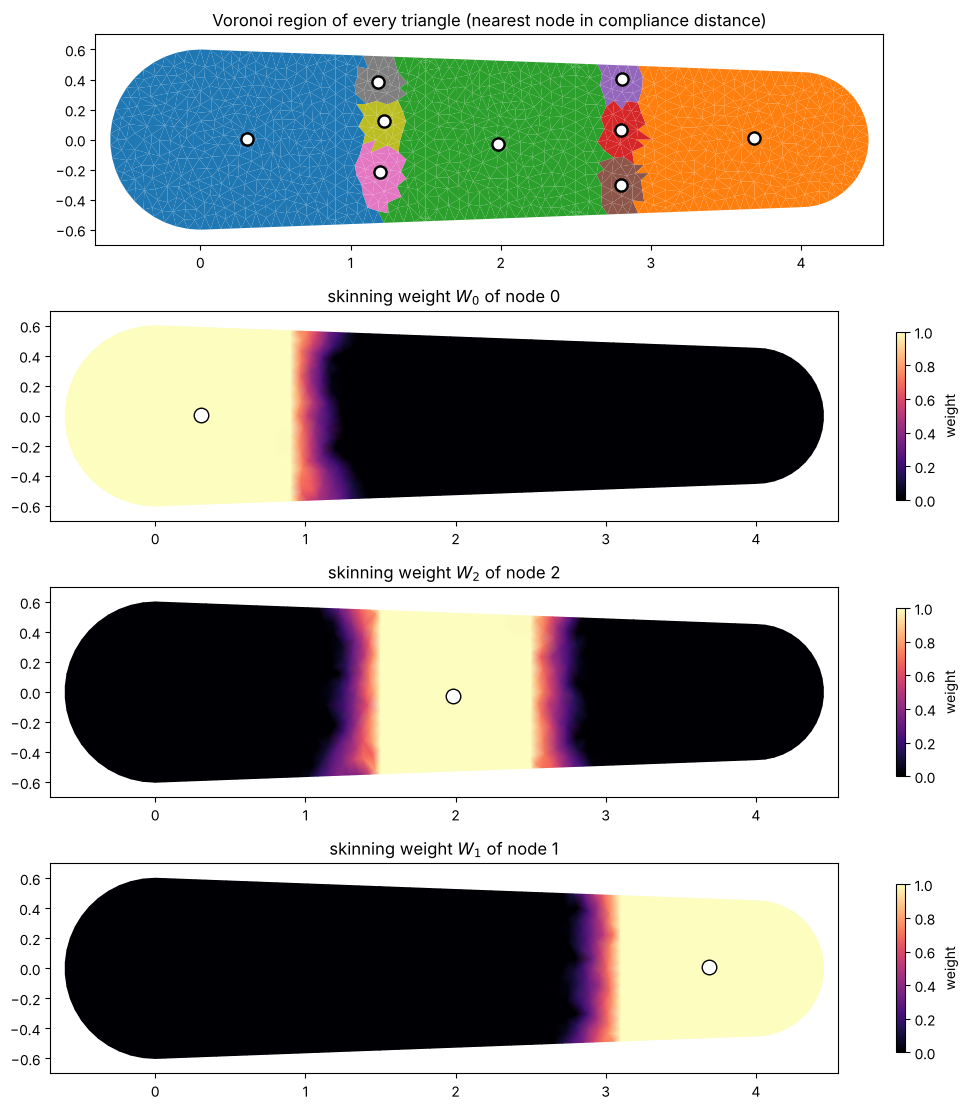

In [5]:
D_nodes = simkit.compliance_distances(G_compliance, nodes)                 # (k, n)
vertex_labels, face_labels = simkit.voronoi_labels(D_nodes, T)
W = simkit.voronoi_shape_functions(D_nodes, nodes, support_scale=SUPPORT_SCALE)  # sparse (n, k)
k = len(nodes)
bone_nodes = [j for j in np.argsort(X[nodes, 0]) if not in_joint(nodes[[j]])[0]][:N_WEIGHTS_SHOWN]
print(f"W: {W.shape}, {W.nnz} non-zeros ({W.nnz / np.prod(W.shape) * 100:.0f}% dense)")
print(f"  partition of unity : max |row sum - 1| = {np.abs(W.sum(axis=1).A.ravel() - 1).max():.1e}")
print(f"  non-negative       : min W = {W.min():.1e}")
print(f"  interpolating      : max |W[nodes] - I| = {np.abs(W[nodes].toarray() - np.eye(k)).max():.1e}")

fig, axes = plt.subplots(1 + len(bone_nodes), 1, figsize=(12, 2.8 * (1 + len(bone_nodes))))
utils.plot_scalar_field(axes[0], X, T, face_labels, cmap="tab10", vmin=-0.5, vmax=9.5, edges=False, colorbar=False,
                        title="Voronoi region of every triangle (nearest node in compliance distance)")
axes[0].scatter(*X[nodes].T, s=90, color="k", zorder=6); axes[0].scatter(*X[nodes].T, s=36, color="w", zorder=7)
for ax, j in zip(axes[1:], bone_nodes):
    utils.plot_scalar_field(ax, X, T, W[:, j].toarray().ravel(), cmap="magma", vmin=0, vmax=1, edges=False,
                            label="weight", title=f"skinning weight $W_{{{j}}}$ of node {j}")
    ax.scatter(*X[nodes[j]], s=110, color="w", edgecolors="k", zorder=6)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "weights.png"),
                              copy_to=os.path.join(MEDIA_DIR, "026_weights.png"))
plt.show()

## 5 &middot; A sparse skinning subspace

Each node carries a $2\times3$ affine frame, so the subspace is $x = B\,z$ with $r = 6k$ coordinates. Tutorial&nbsp;17
built this $B$ dense with `simkit.lbs_jacobian`; the same call with `sparse=True` assembles only the non-zeros of $W$ and
returns a `csr_matrix` with the identical layout, which is what keeps a model with hundreds of local frames cheap. The
printout checks that the two agree. Then the **patch test**: because the weights sum to one, giving every frame the same
affine map reproduces that map on the whole body, and `simkit.lbs_affine_coordinates` writes down the $z$ that does it.
The rest state is the identity map, so no projection is needed to start a simulation in this subspace.

B: (2186, 54), 16194 non-zeros (14% dense); max |sparse - dense| = 0.0e+00
patch test: max |B z - (R X + t)| = 1.8e-15;  rest: max |B z_rest - X| = 8.9e-16


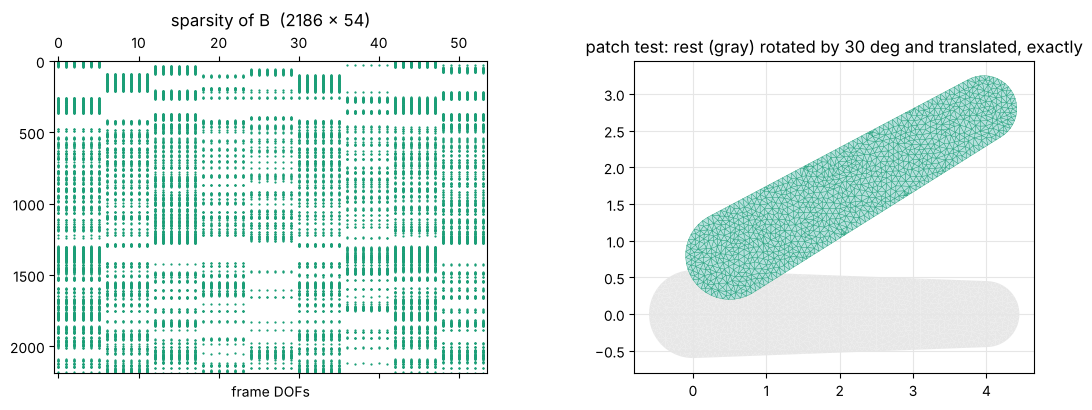

In [6]:
B_sm = simkit.lbs_jacobian(X, W, sparse=True)                   # (n*dim, 6k), sparse
B_dense = simkit.lbs_jacobian(X, W.toarray())                   # the same, dense
print(f"B: {B_sm.shape}, {B_sm.nnz} non-zeros ({B_sm.nnz / np.prod(B_sm.shape) * 100:.0f}% dense); "
      f"max |sparse - dense| = {np.abs(B_sm.toarray() - B_dense).max():.1e}")

th = np.deg2rad(PATCH_ANGLE_DEG)
R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
t_patch = np.array([0.5, 0.8])
z_patch = simkit.lbs_affine_coordinates(k, R, t_patch)          # every frame = the same map x -> R x + t
x_patch = (B_sm @ z_patch).reshape(n, dim)
z_rest = simkit.lbs_affine_coordinates(k, np.eye(dim), np.zeros(dim))
print(f"patch test: max |B z - (R X + t)| = {np.abs(x_patch - (X @ R.T + t_patch)).max():.1e};  "
      f"rest: max |B z_rest - X| = {np.abs((B_sm @ z_rest).reshape(n, dim) - X).max():.1e}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1, 1.6]})
axL.spy(B_sm, markersize=0.6, color=SM_C, aspect="auto")
axL.set_title(f"sparsity of B  ({B_sm.shape[0]} x {B_sm.shape[1]})"); axL.set_xlabel("frame DOFs")
lims = utils.auto_limits([X, x_patch], pad=0.2)
utils.PolyMeshArtist(axR, X, T, facecolor="0.9", edgecolor="none", zorder=1)
utils.plot_mesh(axR, x_patch, T, lims=lims, lw=0.3, facecolor="#b2dfdb", edgecolor=SM_C,
                title=f"patch test: rest (gray) rotated by {PATCH_ANGLE_DEG:.0f} deg and translated, exactly")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "subspace.png"),
                              copy_to=os.path.join(MEDIA_DIR, "026_subspace.png"))
plt.show()

## 6 &middot; Statics in three spaces

`tentacle_operators` builds the constant operators once: the deformation Jacobian, triangle areas, the per-element Lamé
parameters, the lumped mass matrix (for mass-norm errors), the gravity force and the soft pin at the base.
`subspace_statics_system` is the elastostatic problem of tutorial&nbsp;4 written in subspace coordinates, $x = Bz + q$,
with full integration and a Galerkin projection of the gradient and Hessian; with $B = I$ it is the full FEM problem.
Each term is its own line and the total sums them.

$$x^\star = \arg\min_x\; \Psi_{\text{neo}}(x) \;-\; f_g^{\top}x \;+\; \tfrac12\lVert x_{\text{pin}} - X_{\text{pin}}\rVert_K^2
\;+\; \tfrac12\lVert x_{\text{handle}} - y\rVert_K^2 .$$

In [7]:
def tentacle_operators(X, T, mu, lam):
    """Constant operators of the pinned heterogeneous tentacle, built once from simkit."""
    n, dim = X.shape
    Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, K_PIN)
    M_vertex = simkit.massmatrix(X, T, rho=RHO)
    ops = {
        "n": n, "dim": dim,
        "J": simkit.deformation_jacobian(X, T),
        "vol": simkit.volume(X, T),
        "mu": mu, "lam": lam,
        "M": sp.sparse.kron(M_vertex, sp.sparse.eye(dim)).tocsc(),
        "f_g": simkit.gravity_force(X, T, a=GRAVITY, rho=RHO).reshape(-1, 1),
        "Q_pin": Q_pin, "b_pin": b_pin,
    }
    return ops

def subspace_statics_system(ops, B, q, handle_targets=None):
    """Elastostatics (gravity + base pin + optional handle) in subspace coordinates z, where x = B z + q."""
    n, dim = ops["n"], ops["dim"]
    J, vol, mu, lam = ops["J"], ops["vol"], ops["mu"], ops["lam"]
    f_g, Q_pin, b_pin = ops["f_g"], ops["Q_pin"], ops["b_pin"]
    if handle_targets is None:
        Q_h, b_h = sp.sparse.csc_matrix((n * dim, n * dim)), np.zeros((n * dim, 1))
    else:
        Q_h, b_h = simkit.dirichlet_penalty(handle_idx, handle_targets, n, K_PIN)

    def energy_func(z):
        x = B @ z + q
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        E_gravity = -(f_g.T @ x).item()
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_handle = simkit.energies.quadratic_energy(x, Q_h, b_h)
        E_total = E_elastic + E_gravity + E_pin + E_handle
        return E_total

    def gradient_func(z):
        x = B @ z + q
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        g_gravity = -f_g
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_handle = simkit.energies.quadratic_gradient(x, Q_h, b_h)
        g_total = g_elastic + g_gravity + g_pin + g_handle
        g_z = B.T @ g_total                                   # Galerkin projection
        return g_z

    def hessian_func(z):
        x = B @ z + q
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL, psd=True)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_handle = simkit.energies.quadratic_hessian(Q_h)
        H_total = H_elastic + H_pin + H_handle
        H_z = B.T @ (H_total @ B)                             # Galerkin projection
        return H_z

    return energy_func, gradient_func, hessian_func

ops = tentacle_operators(X, T, mu, lam)

The three spaces: **full FEM** ($B = I$), **skinning eigenmodes** with nine bones (`simkit.skinning_eigenmodes`, the
geometry-only basis of tutorial&nbsp;17, started from the mass-norm projection of the rest shape), and the **sparse meshless**
basis with nine frames, started from $z_{\text{rest}}$. Both subspaces have exactly $54$ DOFs. `solve_statics` runs Newton
with line search from a given start, and we let the tentacle sag under gravity in each space. The error is the relative
mass-norm distance to the full solution.

In [8]:
W_skin, _, B_skin = simkit.skinning_eigenmodes(X, T, N_NODES)       # 6 Laplacian-eigenvector bones, 36 DOFs
x_rest = X.reshape(-1, 1)
spaces = {
    f"full FEM  ({X.size} DOFs)": (sp.sparse.identity(X.size, format="csc"), np.zeros((X.size, 1)), x_rest.copy()),
    f"skinning eigenmodes  ({B_skin.shape[1]} DOFs)": (B_skin, np.zeros((X.size, 1)),
                                                        simkit.project_into_subspace(x_rest, B_skin, M=ops["M"])),
    f"sparse meshless  ({B_sm.shape[1]} DOFs)": (B_sm, np.zeros((X.size, 1)), z_rest.copy()),
}
space_colors = dict(zip(spaces, [FULL_C, SKIN_C, SM_C]))

def solve_statics(B, q, z0, handle_targets=None):
    """Newton solve of the static tentacle in the subspace x = B z + q, from z0. Returns (x, z, iterations)."""
    system = subspace_statics_system(ops, B, q, handle_targets)
    z, info = simkit.solvers.newton_solver(z0, *system, tolerance=NEWTON_TOL, max_iter=NEWTON_ITERS,
                                           do_line_search=True, return_info=True)
    x = (B @ z + q).reshape(n, dim)
    return x, z, info["iters"] + 1

def mass_norm_error(x, x_ref):
    """Relative mass-norm distance between two stacked positions."""
    d = (x - x_ref).reshape(-1, 1)
    M = ops["M"]
    return np.sqrt((d.T @ M @ d).item() / (x_ref.reshape(-1, 1).T @ M @ x_ref.reshape(-1, 1)).item())

sag = {}
for name, (B, q, z0) in spaces.items():
    sag[name], _, iters = solve_statics(B, q, z0)
    print(f"{name:36s}: tip height {sag[name][tip, 1]:+.3f}, {iters} Newton iterations")
x_full = sag[next(iter(spaces))]
for name in list(spaces)[1:]:
    print(f"{name:36s}: relative mass-norm error vs full = {mass_norm_error(sag[name], x_full):.3f}")

full FEM  (2186 DOFs)               : tip height -0.772, 31 Newton iterations
skinning eigenmodes  (54 DOFs)      : tip height +0.026, 3 Newton iterations


sparse meshless  (54 DOFs)          : tip height -0.477, 22 Newton iterations
skinning eigenmodes  (54 DOFs)      : relative mass-norm error vs full = 0.149
sparse meshless  (54 DOFs)          : relative mass-norm error vs full = 0.054


The sag, each subspace (thin, coloured) over the full solution (thick, light red). Skinning eigenmodes bend the body
smoothly everywhere, stiff segments included; bending a segment costs a thousand times more than bending a joint, so the
subspace barely moves and the tip stays up. The sparse meshless frames keep the segments straight and fold the joints,
recovering well over half of the full sag with the same $54$ DOFs; what is missing is the shape of the fold, a linear
blend of two frames across the joint instead of the full solve's bending profile. The lower row shows where the material
strains: the area ratio $\det F$ of every triangle, which the sparse model concentrates in the joints like the full
solve, while the skinning subspace strains nothing.

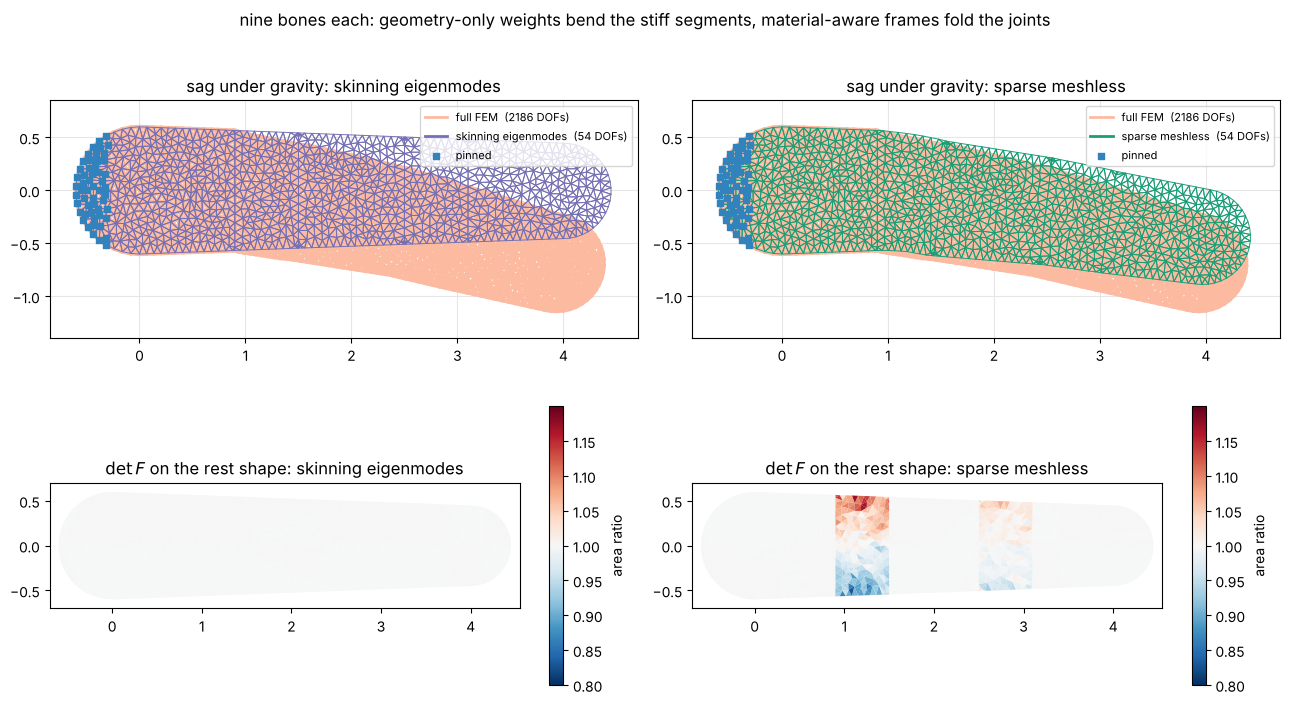

In [9]:
lims = utils.auto_limits(list(sag.values()), pad=0.25)
names = list(spaces)
fig, axes = plt.subplots(2, 2, figsize=(13, 7.4))
for ax, name in zip(axes[0], names[1:]):
    utils.plot_mesh_overlay(ax, {names[0]: x_full, name: sag[name]}, T,
                            colors={names[0]: "#fcbba1", name: space_colors[name]}, lws={names[0]: 3.0, name: 0.7},
                            pin_pts=X[pin_idx], lims=lims, title=f"sag under gravity: {name.split('  ')[0]}")
    ax.legend(loc="upper right", fontsize=8)
area_ratio = {name: np.linalg.det((ops["J"] @ x.reshape(-1, 1)).reshape(-1, dim, dim)) for name, x in sag.items()}
norm = TwoSlopeNorm(vmin=0.8, vcenter=1.0, vmax=1.2)
for ax, name in zip(axes[1], names[1:]):
    utils.plot_scalar_field(ax, X, T, area_ratio[name], cmap="RdBu_r", norm=norm, edges=False, label="area ratio",
                            title=f"$\\det F$ on the rest shape: {name.split('  ')[0]}")
fig.suptitle("nine bones each: geometry-only weights bend the stiff segments, material-aware frames fold the joints")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "sag.png"),
                              copy_to=os.path.join(MEDIA_DIR, "026_sag.png"))
plt.show()

## 7 &middot; Does adding frames fix it?

`sag_in_subspace` repeats the gravity solve for both subspaces at each frame count of the sweep (same number of bones,
so the same DOFs) and we plot the tip height against the full solve. The sparse meshless model approaches the full
solution as frames are added, mostly inside the joints where the compliance metric puts them; the curve is not
monotone because farthest-point sampling decides where each extra frame lands. Skinning eigenmodes stay rigid at every
size: a smooth basis has to bend a stiff segment to bend a joint.

k= 3 ( 18 DOFs): sparse meshless  42% of the full sag, skinning eigenmodes  -4%
k= 6 ( 36 DOFs): sparse meshless  40% of the full sag, skinning eigenmodes  -4%
k= 9 ( 54 DOFs): sparse meshless  62% of the full sag, skinning eigenmodes  -3%
k=12 ( 72 DOFs): sparse meshless  72% of the full sag, skinning eigenmodes  -3%
k=18 (108 DOFs): sparse meshless  81% of the full sag, skinning eigenmodes  -3%
k=24 (144 DOFs): sparse meshless  86% of the full sag, skinning eigenmodes  -3%


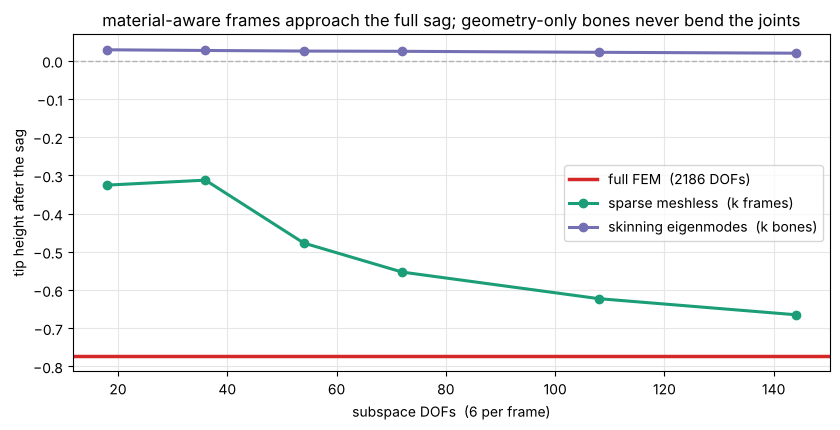

In [10]:
def sag_in_subspace(k):
    """Tip height of the gravity sag with k sparse meshless frames and with k skinning eigenmode bones."""
    nodes_k = simkit.compliance_node_sampling(X, G_compliance, k, lloyd_iters=LLOYD_ITERS)
    W_k = simkit.voronoi_shape_functions(simkit.compliance_distances(G_compliance, nodes_k), nodes_k,
                                         support_scale=SUPPORT_SCALE)
    B_k = simkit.lbs_jacobian(X, W_k, sparse=True)
    x_sm, _, _ = solve_statics(B_k, np.zeros((X.size, 1)), simkit.lbs_affine_coordinates(k, np.eye(dim), np.zeros(dim)))
    _, _, B_sk = simkit.skinning_eigenmodes(X, T, k)
    x_sk, _, _ = solve_statics(B_sk, np.zeros((X.size, 1)), simkit.project_into_subspace(x_rest, B_sk, M=ops["M"]))
    return x_sm[tip, 1], x_sk[tip, 1]

sweep = np.array([sag_in_subspace(k) for k in SWEEP_NODES])
dofs = 6 * np.array(SWEEP_NODES)
for k, (t_sm, t_sk) in zip(SWEEP_NODES, sweep):
    print(f"k={k:2d} ({6 * k:3d} DOFs): sparse meshless {t_sm / x_full[tip, 1] * 100:3.0f}% of the full sag, "
          f"skinning eigenmodes {t_sk / x_full[tip, 1] * 100:3.0f}%")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.axhline(x_full[tip, 1], color=FULL_C, lw=2.5, label=f"full FEM  ({X.size} DOFs)")
ax.plot(dofs, sweep[:, 0], "-o", color=SM_C, lw=2.2, ms=6, label="sparse meshless  (k frames)")
ax.plot(dofs, sweep[:, 1], "-o", color=SKIN_C, lw=2.2, ms=6, label="skinning eigenmodes  (k bones)")
ax.axhline(0.0, color="0.7", lw=1, ls="--")
ax.set_xlabel("subspace DOFs  (6 per frame)"); ax.set_ylabel("tip height after the sag")
ax.set_title("material-aware frames approach the full sag; geometry-only bones never bend the joints")
ax.grid(True, color="0.9"); ax.legend(loc="center right")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "026_convergence.png"))
plt.show()

## 8 &middot; Swinging the free end

A stiff handle drags the tip cap of the tentacle (rotated about the base) through an arc of $\pm40^\circ$,
re-solving the statics in each space at every frame, warm-started from the previous one. The animation plays the three
spaces side by side with the full solution ghosted in gray under each subspace, and the plot tracks each subspace's error
over the sweep. The handle fixes where the tip goes, so both subspaces are close to the full solution there; the
difference is in between, where the sparse meshless model folds the joints and the skinning basis bends the segments.

In [11]:
angles = np.deg2rad(SWING_DEG) * np.sin(np.linspace(0, 2 * np.pi, N_FRAMES))
pivot = X[pin_idx].mean(axis=0)
states = {name: [] for name in spaces}
errors = {name: [] for name in names[1:]}
z_curr = {name: z0.copy() for name, (_, _, z0) in spaces.items()}
for th in angles:
    R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
    targets = (X[handle_idx] - pivot) @ R.T + pivot             # tip cap swung about the pinned base
    for name, (B, q, _) in spaces.items():
        x, z_curr[name], _ = solve_statics(B, q, z_curr[name], targets)
        states[name].append(x)
    for name in names[1:]:
        errors[name].append(mass_norm_error(states[name][-1], states[names[0]][-1]))
for name in names[1:]:
    print(f"{name:36s}: mean error over the sweep {np.mean(errors[name]):.3f}, max {np.max(errors[name]):.3f}")

lims = utils.auto_limits(sum(states.values(), []), pad=0.2)
panels = [{"states": states[names[0]], "T": T, "title": names[0], "color": "#fcbba1"}]
for name in names[1:]:
    panels.append({"states": states[name], "T": T, "title": name, "color": space_colors[name],
                   "ghost": states[names[0]]})
fig, anim = utils.animate_colored_mesh_panels(panels, lims=lims, fps=FPS, figsize=(16, 5.0),
                                              suptitle="the free end swung through an arc, solved in three spaces")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "swing.mp4"), fps=FPS, bitrate=BITRATE,
                                         copy_to=os.path.join(MEDIA_DIR, "026_swing.mp4"))
plt.close(fig)
utils.embed_video(video)

skinning eigenmodes  (54 DOFs)      : mean error over the sweep 0.025, max 0.041
sparse meshless  (54 DOFs)          : mean error over the sweep 0.009, max 0.015


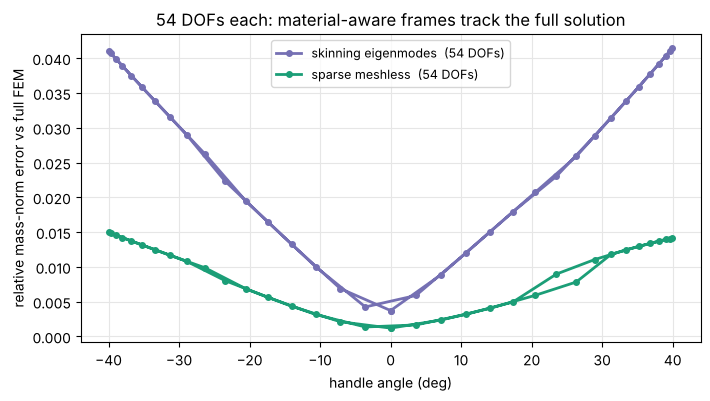

In [12]:
fig, ax = utils.line_plot(np.rad2deg(angles), errors, colors=space_colors, xlabel="handle angle (deg)",
                          ylabel="relative mass-norm error vs full FEM", figsize=(8, 4),
                          title=f"{B_sm.shape[1]} DOFs each: material-aware frames track the full solution", markers=True)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "swing_error.png"),
                              copy_to=os.path.join(MEDIA_DIR, "026_swing_error.png"))
plt.show()

### Takeaways

* The **compliance distance** prices a path by $\int \mathrm{d}s / E$: a stiff segment collapses to nearly a point, a soft
  joint stretches into a long one. Everything else in the method is ordinary (farthest-point sampling, Voronoi regions, linear tents,
  linear blend skinning) but computed in that metric.
* Nodes therefore go **where the deformation is** (the joints), and the Voronoi weights stop at material interfaces instead
  of smearing across them, so a stiff segment is covered by constant weights and stays rigid for free.
* The subspace is plain LBS with affine frames, $x = Bz$, so it reproduces every rigid and affine motion exactly (the patch
  test) and the rest state is $z_{\text{rest}}$ with no projection. `simkit.lbs_jacobian(..., sparse=True)` keeps $B$ sparse,
  which is what makes many local frames affordable.
* With the **same number of bones**, geometry-only skinning eigenmodes bend the stiff segments and miss the sag at every
  size, while the material-aware frames fold the joints and approach the full solution as frames are added. Pre-seed one
  node per rigid part (`seed_nodes`) when a segment must be exactly rigid, as the paper recommends.
* One affine frame cannot serve a rigid bone *and* a thick layer of soft flesh wrapped around it: the flesh would have to
  deform while its frame stays rigid. Bodies with embedded bones need frames in the flesh as well, many more than the
  joints alone; here the stiff segments span the full thickness, which is the regime a sparse model handles well.